# Gaussian CGO: certified bounds from a covariance

`CGO/GaussianCGO.py` implements the commutator gauge optimization for a **Gaussian**
state.  Nothing here knows about `GfPEPS`: the whole construction turns around one
real antisymmetric covariance matrix.

* the **internal** Majoranas carry the patch subspace
  $V_L = \mathrm{span}\{\gamma_S|\Gamma\rangle : S \subseteq \text{half of the internal bonds}\}$,
  which is the excitation family of `majorana_gram`, and `project` / `compress` express
  every operator in an orthonormal basis of it;
* the **external** Majoranas carry the observable $B$, the patch Hamiltonian
  $H_L$, and the sampled operators $A_i$;
* the bounds are the two ends of

$$\min / \max\ \mathrm{Tr}(\sigma B)\quad \text{s.t.}\quad \sigma \succeq 0,\
\mathrm{Tr}\,\sigma = 1,\ \mathrm{Tr}(\sigma M_i) = 0,\qquad
M_i = P_V[H_L, A_i]P_V,$$

  which `CGO` assembles and hands to `cvxpy`.

The notebook walks through the four numerical facts we found on the way: the premise
holds exactly, the SDP tightens the basic interval by a large factor, the interval
collapses onto the exact value when $B$ lies in the span of the constraints, and the
family of $A_i$ has to match the parity of the observable.


In [1]:
import itertools

import torch

from base import CUDA
from FreeFermion.linalg import RandPureCov
from GaussianCGO import GaussianCGO

torch.manual_seed(0)

MODES = 8
cgo = GaussianCGO(RandPureCov(2 * MODES), list(range(8)))
print(f'size {cgo.size} = the dimension of the patch subspace')
print(f'internal {cgo.internal}')
print(f'basis    {cgo.basis}   (the first half of internal generates the basis)')
print(f'external {cgo.external}')
print(f'H_L: {len(cgo.patch_hamiltonian())} bilinears on the external'
      f', one per pair of {len(cgo.external)} Majoranas')


size 16 = the dimension of the patch subspace
internal [0, 1, 2, 3, 4, 5, 6, 7]
basis    [0, 1, 2, 3]   (the first half of internal generates the basis)
external [8, 9, 10, 11, 12, 13, 14, 15]
H_L: 28 bilinears on the external, one per pair of 8 Majoranas


## 1. The constraints hold for the state exactly

The certificate is only valid if the state itself satisfies the constraints, that is if
every $\langle [H_L, A_i]\rangle$ vanishes.  A monomial is made anti-Hermitian by the
factor $i$ exactly when $\gamma_A^\dagger = (-1)^{|A|(|A|-1)/2}\gamma_A$ is $+\gamma_A$,
which is what `enumerate_operators` does, and the commutator with the quadratic $H_L$ is
then Hermitian, as the assertion inside `compress` insists.


In [2]:
print(f'{"degree":>6} {"constraints":>12} {"max |<[H_L, A_i]>|":>21}')
for degree in (1, 2, 3, 4):
    family = cgo.enumerate_operators(degree)
    values = [abs(cgo.by_wick(cgo.commutator(cgo.patch_hamiltonian(), A))) for A in family]
    print(f'{degree:>6} {len(family):>12} {max(values):>21.1e}')


degree  constraints    max |<[H_L, A_i]>|
     1            8               0.0e+00
     2           28               7.8e-16
     3           56               0.0e+00
     4           70               3.3e-16


## 2. The basic interval versus CGO

`basic_CGO` is the eigenvalue range of $P_V B P_V$; `CGO` adds the vanishing commutators
and solves the SDP.  The observable below is a quartic on the external Majoranas, which
is even under parity, so the even degree 2 family is the one that bites.


In [5]:
observable = [(1.0, [8, 9, 10, 11])]
exact = cgo.by_wick(observable)
basic = cgo.basic_CGO(observable)

print(f'exact <O> = {exact:+.9f}')
print(f'\n{"bounds":>12} {"lower":>13} {"upper":>13} {"width":>11} {"gain":>8} '
      f'{"residual":>10}  exact inside')
print(f'{"basic":>12} {basic[0]:>13.9f} {basic[1]:>13.9f} {basic[1] - basic[0]:>11.3e} '
      f'{"1.0":>8} {"-":>10}  {basic[0] <= exact <= basic[1]}')
for degree in (1, 2, 3, 4):
    lower, upper, info = cgo.CGO(observable, degree=degree, return_info=True, eps=1e-9)
    print(f'{"CGO " + str(degree):>12} {lower:>13.9f} {upper:>13.9f} {upper - lower:>11.3e} '
          f'{(basic[1] - basic[0]) / (upper - lower):>8.1f} {info["residual"]:>10.1e}  '
          f'{lower - 1e-7 <= exact <= upper + 1e-7}')


exact <O> = -0.037421763

      bounds         lower         upper       width     gain   residual  exact inside
       basic  -0.189479529   0.330772891   5.203e-01      1.0          -  True
       CGO 1  -0.189479529   0.330772891   5.203e-01      1.0    7.0e-14  True
       CGO 2  -0.041633134  -0.034163912   7.469e-03     69.7    5.8e-15  True
       CGO 3  -0.189479529   0.330772891   5.203e-01      1.0    5.4e-14  True
       CGO 4  -0.037421763  -0.037421763   6.939e-18 74976275383074304.0    4.3e-15  True


## 3. When the interval collapses onto the exact value

The SDP is a linear functional on a spectrahedron, so if $B$ happens to lie in
$\mathrm{span}\{I, M_i\}$ then $\mathrm{Tr}(\sigma B)$ is *constant* on the feasible set
and the two bounds must meet.  That is exactly what the near zero widths above are, and
the span test below predicts which rows of the table collapse.


In [6]:
def as_vector(matrix):
    """A Hermitian matrix as a real vector, for the span test."""
    return (matrix.real + matrix.imag).reshape(-1)


print(f'{"observable":>22} {"degree":>7} {"residual":>11} {"|B|":>8}  in span')
for name, operator in (('i g8 g9 (even)', [(1j, [8, 9])]),
                       ('g8 (odd)', [(1.0, [8])]),
                       ('g8 g9 g10 g11 (even)', [(1.0, [8, 9, 10, 11])])):
    B = cgo.compress(cgo.project(operator))
    for degree in (1, 2, 3):
        rows = [as_vector(torch.eye(cgo.size, dtype=torch.complex128, device=CUDA))]
        rows += [as_vector(cgo.compress(cgo.project(cgo.commutator(cgo.patch_hamiltonian(), A))))
                 for A in cgo.enumerate_operators(degree)]
        basis, target = torch.stack(rows), as_vector(B)
        solution = torch.linalg.lstsq(basis.T, target.unsqueeze(1)).solution
        residual = float((basis.T @ solution - target.unsqueeze(1)).norm())
        print(f'{name:>22} {degree:>7} {residual:>11.2e} {float(target.norm()):>8.4f}  '
              f'{residual < 1e-8 * float(target.norm())}')


            observable  degree    residual      |B|  in span
        i g8 g9 (even)       1    7.63e-01   1.1640  False
        i g8 g9 (even)       2    5.84e-15   1.1640  True
        i g8 g9 (even)       3    7.63e-01   1.1640  False
              g8 (odd)       1    5.57e-16   1.6659  True
              g8 (odd)       2    1.68e+00   1.6659  False
              g8 (odd)       3    6.05e-16   1.6659  True
  g8 g9 g10 g11 (even)       1    9.97e-01   1.0331  False
  g8 g9 g10 g11 (even)       2    3.93e-02   1.0331  False
  g8 g9 g10 g11 (even)       3    9.97e-01   1.0331  False


## 4. The family has to match the parity of the observable

A degree $k$ family produces commutators of the same parity as $k$, while the projected
operator of the observable is block diagonal in parity when it is even and off block
diagonal when it is odd.  Matching the parity is what brings the interval down, by the
factor of the table in section 2; the wrong parity still cuts, but only slightly.  The
collapsed rows below print widths of order $10^{-15}$, which are numerical zeros, and the
negative sign on some of them is the solver's tolerance rather than a real ordering.


In [7]:
print(f'{"observable":>22} {"degree":>7} {"width":>11} {"basic width":>12}  exact inside')
for name, operator in (('i g8 g9 (even)', [(1j, [8, 9])]),
                       ('g8 (odd)', [(1.0, [8])]),
                       ('g8 g9 g10 g11 (even)', [(1.0, [8, 9, 10, 11])])):
    exact = cgo.by_wick(operator)
    basic = cgo.basic_CGO(operator)
    for degree in (1, 2):
        lower, upper = cgo.CGO(operator, degree=degree, eps=1e-9)
        print(f'{name:>22} {degree:>7} {upper - lower:>11.3e} {basic[1] - basic[0]:>12.3e}  '
              f'{lower - 1e-7 <= exact <= upper + 1e-7}')


            observable  degree       width  basic width  exact inside
        i g8 g9 (even)       1   3.813e-01    3.813e-01  True
        i g8 g9 (even)       2  -2.665e-15    3.813e-01  True
              g8 (odd)       1  -9.532e-16    8.329e-01  True
              g8 (odd)       2   6.714e-01    8.329e-01  True
  g8 g9 g10 g11 (even)       1   5.203e-01    5.203e-01  True
  g8 g9 g10 g11 (even)       2   7.469e-03    5.203e-01  True


## 5. The constraint value is zero, the constraint operator is not

Section 1 checks the expectation of $[H_L,A_i]$, of order $10^{-16}$ (exactly zero for
the odd degrees).  That number is what makes the certificate valid -- the true state has
to be feasible -- but it is not what makes CGO useful.  In the patch basis the state sits
at the empty index $S=T=0$, so the expectation is a *single entry* of the raw projected
commutator

$$R_i[S,T]=\langle S|[H_L,A_i]|T\rangle,\qquad R_i[0,0]=\langle[H_L,A_i]\rangle ,$$

while the SDP constrains the whole compressed matrix $M_i$.  The table and the heatmaps
below show the two scales side by side: the boxed $[0,0]$ entry is the $10^{-16}$ of
section 1, and the remaining entries are of order $1$ -- they are the correlation between
the internal bonds that generate $V_L$ and the external bonds that carry $H_L$ and $A_i$.
A matrix is not zero because one of its entries is, which is why the same constraints
still narrow the interval by a large factor in section 2.  The contrast is a *product*
state across the cut, where every entry collapses onto that same expectation: then
$M_i=0$ identically and CGO falls back to the basic algorithm.

Each panel draws one degree 2 constraint as its real part (left half) and imaginary part
(right half); the raw matrix is Hermitian, so the real part is symmetric and the imaginary
part antisymmetric.  The four largest constraints of the family are shown, on a shared
colour scale, with the $[0,0]$ entry boxed.


degree constraints max |<[H_L, A_i]>|  max |R_i|  max |M_i| state entry / matrix scale
     1           8            0.0e+00      0.631      0.631                    0.0e+00
     2          28            7.8e-16      0.405      0.498                    1.9e-15
     3          56            0.0e+00      0.441      0.567                    0.0e+00
     4          70            3.3e-16      0.353      0.455                    9.4e-16
the [0,0] entry is the section-1 number: largest difference 0.0e+00


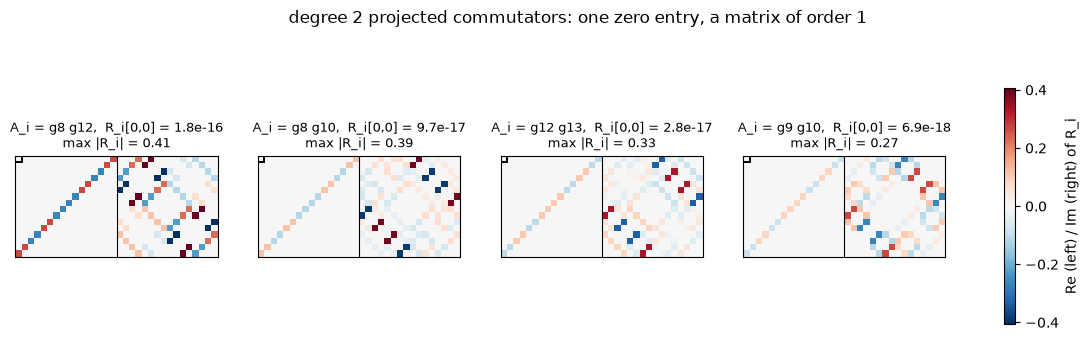

In [4]:
import matplotlib.pyplot as plt

H = cgo.patch_hamiltonian()
projected = {}
print(f'{"degree":>6} {"constraints":>11} {"max |<[H_L, A_i]>|":>18} {"max |R_i|":>10} '
      f'{"max |M_i|":>10} {"state entry / matrix scale":>26}')
for degree in (1, 2, 3, 4):
    family = cgo.enumerate_operators(degree)
    # project reads an empty string as the identity, so a vanishing commutator is dropped
    terms = [term for term in (cgo.commutator(H, A) for A in family) if term]
    # a small patch can kill a whole family, e.g. the degree 4 parity of 4 external bonds
    if not terms:
        continue
    raw = [cgo.project(term) for term in terms]
    values = [abs(cgo.by_wick(term)) for term in terms]
    scale = max(float(R.abs().max()) for R in raw)
    projected[degree] = (family, raw, values)
    print(f'{degree:>6} {len(family):>11} {max(values):>18.1e} {scale:>10.3f} '
          f'{max(float(cgo.compress(R).abs().max()) for R in raw):>10.3f} '
          f'{max(values) / scale:>26.1e}')

family, raw, values = projected[2]
print(f'the [0,0] entry is the section-1 number: largest difference '
      f'{max(abs(abs(float(R[0, 0].real)) - value) for R, value in zip(raw, values)):.1e}')

# the four largest degree 2 constraints, on one shared colour scale
ordered = sorted(zip(raw, family), key=lambda pair: float(pair[0].abs().max()), reverse=True)[:4]
limit = max(float(R.abs().max()) for R, _ in ordered)
figure, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for axis, (R, A) in zip(axes, ordered):
    a, b = A[0][1]
    image = axis.imshow(torch.cat([R.real, R.imag], dim=1).cpu().numpy(),
                        cmap='RdBu_r', vmin=-limit, vmax=limit)
    axis.add_patch(plt.Rectangle((-0.5, -0.5), 1, 1, fill=False, edgecolor='black', lw=1.4))
    axis.axvline(cgo.size - 0.5, color='black', lw=0.8)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_title(f'A_i = g{a} g{b},  R_i[0,0] = {abs(float(R[0, 0].real)):.1e}\n'
                   f'max |R_i| = {float(R.abs().max()):.2f}', fontsize=9)
figure.colorbar(image, ax=list(axes), shrink=0.85, label='Re (left) / Im (right) of R_i')
figure.suptitle('degree 2 projected commutators: one zero entry, a matrix of order 1', y=1.04)
plt.show()


## 6. Notes

* `enumerate_operators(degree)` is deterministic and spans a fixed subspace of the
  Hermitian matrices, which is what makes the bounds reproducible.  `sample_operators`
  draws random strings instead, and a few random directions span much less: on a larger
  system of 24 external Majoranas, 30 random linear constraints reached rank 4 only.
* The exact equalities are feasible here, because the state satisfies every one of them,
  so no tolerance relaxation is needed, unlike the MPS implementation of `CGO`, where
  the truncated subspace forces `constraint_tol`.
* `cvxpy` with `SCS` and `eps=1e-9` solved every case above; `CLARABEL` rejects the `eps`
  keyword (it wants its own option names).
* The collapse of a row is not an approximation: the constraints determine
  $\mathrm{Tr}(\sigma B)$ exactly there.  The genuine finite intervals are the ones
  where $B$ is outside the span, and the quartic observable with the degree 2 family is
  the example kept above.
